In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load results
results_df = pd.read_csv("../data/processed/model_results.csv")
print(results_df)


               Model        MAE       RMSE  R2 Score
0  Linear Regression  40.035255  96.611235  0.328634
1      Decision Tree  11.541620  44.438807  0.857954
2      Random Forest   8.775097  32.573423  0.923681


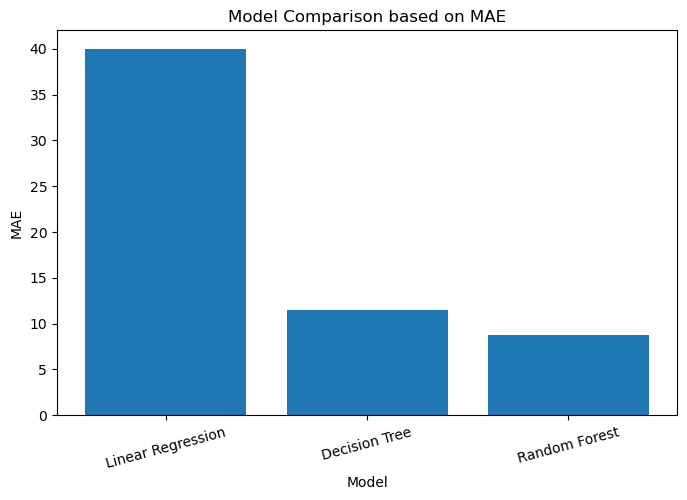

In [3]:
# Bar chart for MAE
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison based on MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()

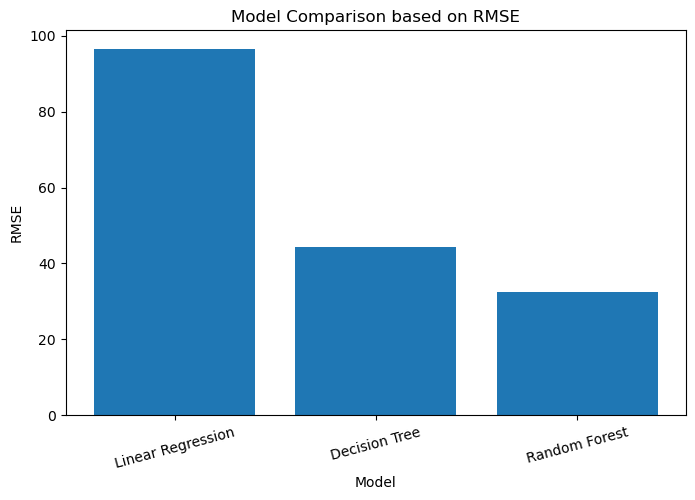

In [4]:
# Bar chart for RMSE
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

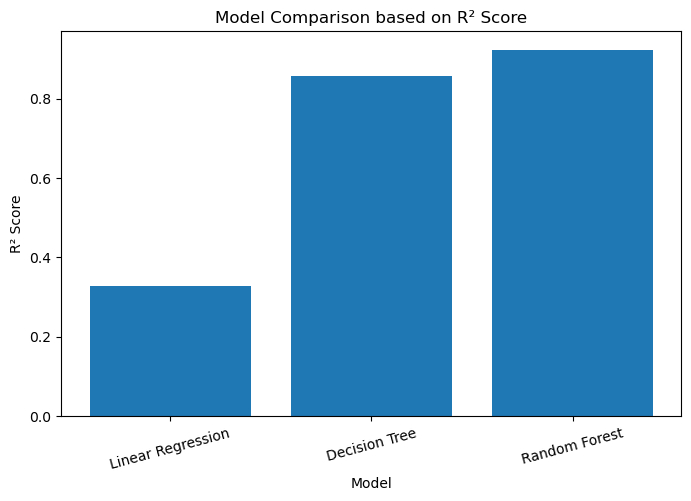

In [5]:
# Bar chart for R2 Score
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.show()

In [6]:
# Load best model
best_model = joblib.load("../models/random_forest_model.pkl")
print("Best model loaded successfully!")

Best model loaded successfully!


In [7]:
# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_test.shape)
print(y_test.shape)

(100000, 1304)
(100000,)


In [8]:
# Predict using best model
predictions = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test[:10].values,
    "Predicted": predictions[:10]
})

print(comparison_df)

   Actual  Predicted
0    29.0      21.58
1   144.0     117.28
2     4.0      10.33
3    46.0      41.61
4    24.0      24.63
5     4.0       4.28
6    25.0      27.64
7    13.0      17.95
8    48.0      42.04
9   310.0     236.39


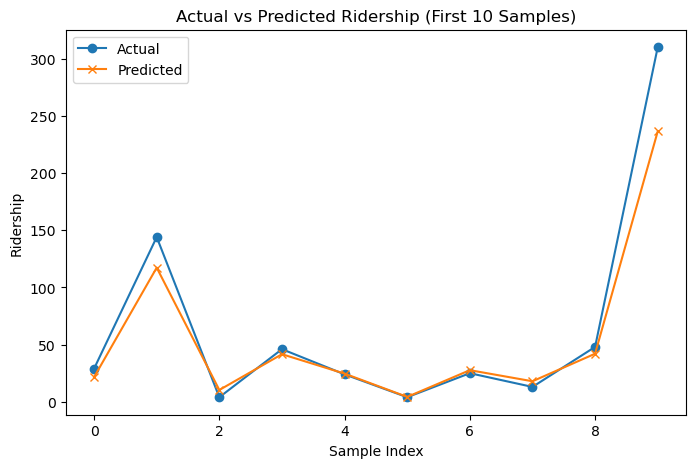

In [12]:
# Plot actual vs predicted
plt.figure(figsize=(8,5))
plt.plot(comparison_df["Actual"].values, label="Actual", marker='o')
plt.plot(comparison_df["Predicted"].values, label="Predicted", marker='x')
plt.title("Actual vs Predicted Ridership (First 10 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Ridership")
plt.legend()
plt.show()

In [13]:
# Save comparison output
comparison_df.to_csv("../data/processed/actual_vs_predicted.csv", index=False)
print("Comparison file saved successfully!")

Comparison file saved successfully!
